<a href="https://colab.research.google.com/github/Seanatist/Seanatist/blob/main/LoanEligibilityProjectDemo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install fairlearn
!pip install streamlit

**Importing dependencies**


In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
)

from fairlearn.metrics import (
    MetricFrame,
    demographic_parity_difference,
    equalized_odds_difference,
)

**Loading the dataset into the notebook**

In [7]:
df_raw = pd.read_csv("/content/Loan_status_prediction.csv")
df_raw.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


**Data cleaning**

In [8]:

TARGET_COL = "Loan_Status"

# Map target to 0/1 if needed (Y/N → 1/0)
if df_raw[TARGET_COL].dtype == "object":
    df_raw[TARGET_COL] = df_raw[TARGET_COL].map({"Y": 1, "N": 0, 1: 1, 0: 0}).astype(int)

def clean_loan_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df = df.drop_duplicates()

    num_cols = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term", "Credit_History"]
    cat_cols = ["Gender", "Married", "Dependents", "Education", "Self_Employed", "Property_Area"]

    # Keeping only columns we actually use + target
    keep_cols = num_cols + cat_cols + [TARGET_COL]
    df = df[keep_cols]

    # Handle missing values
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())
    for col in cat_cols:
        df[col] = df[col].fillna(df[col].mode().iloc[0])

    # Simple sanity filters
    df = df[df["ApplicantIncome"] > 0]
    df = df[df["LoanAmount"] > 0]

    return df

df_clean = clean_loan_data(df_raw)

print("Raw shape:", df_raw.shape)
print("Clean shape:", df_clean.shape)
df_clean.head()

Raw shape: (614, 13)
Clean shape: (614, 12)


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
0,5849,0.0,128.0,360.0,1.0,Male,No,0,Graduate,No,Urban,1
1,4583,1508.0,128.0,360.0,1.0,Male,Yes,1,Graduate,No,Rural,0
2,3000,0.0,66.0,360.0,1.0,Male,Yes,0,Graduate,Yes,Urban,1
3,2583,2358.0,120.0,360.0,1.0,Male,Yes,0,Not Graduate,No,Urban,1
4,6000,0.0,141.0,360.0,1.0,Male,No,0,Graduate,No,Urban,1


**Exploratory Data Analysis**



Shape: (614, 12)

Class balance (Loan_Status):
Loan_Status
1    0.687296
0    0.312704
Name: proportion, dtype: float64

Gender counts:
Gender
Male      502
Female    112
Name: count, dtype: int64

Property_Area counts:
Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64

Numerical summary:


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,614.000000,614.000000,614.000000
mean,5403.459283,1621.245798,145.752443,342.410423,0.855049
std,6109.041673,2926.248369,84.107233,64.428629,0.352339
min,150.000000,0.000000,9.000000,12.000000,0.000000
25%,2877.500000,0.000000,100.250000,360.000000,1.000000
50%,3812.500000,1188.500000,128.000000,360.000000,1.000000
75%,5795.000000,2297.250000,164.750000,360.000000,1.000000
max,81000.000000,41667.000000,700.000000,480.000000,1.000000


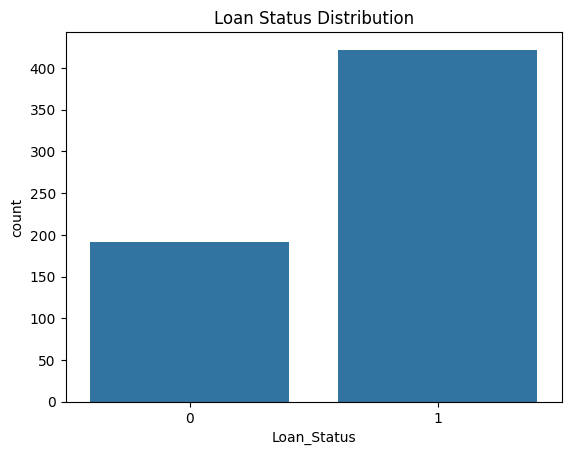

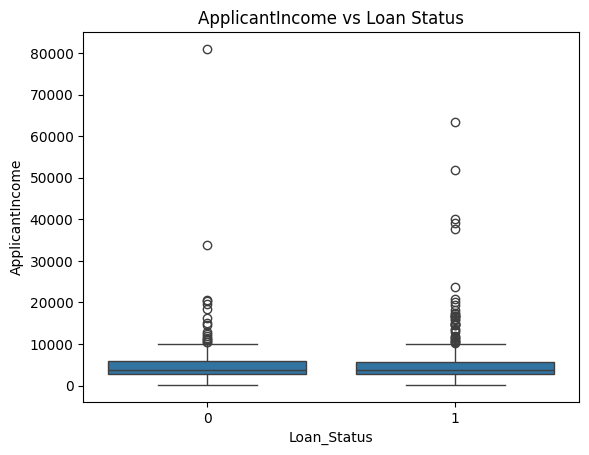

In [9]:
def basic_eda_summary(df: pd.DataFrame) -> dict:
    num_cols = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term", "Credit_History"]
    return {
        "shape": df.shape,
        "numerical_summary": df[num_cols].describe(),
        "class_balance": df[TARGET_COL].value_counts(normalize=True),
        "gender_counts": df["Gender"].value_counts(),
        "property_area_counts": df["Property_Area"].value_counts(),
    }
summary = basic_eda_summary(df_clean)
print("Shape:", summary["shape"])
print("\nClass balance (Loan_Status):")
print(summary["class_balance"])
print("\nGender counts:")
print(summary["gender_counts"])
print("\nProperty_Area counts:")
print(summary["property_area_counts"])
print("\nNumerical summary:")
display(summary["numerical_summary"])
# A couple of quick plots (optional)
sns.countplot(data=df_clean, x=TARGET_COL)
plt.title("Loan Status Distribution")
plt.show()
sns.boxplot(data=df_clean, x=TARGET_COL, y="ApplicantIncome")
plt.title("ApplicantIncome vs Loan Status")
plt.show()

**Train/Test Split**

In [10]:
def train_test_splits(
    df: pd.DataFrame,
    target_col: str = TARGET_COL,
    test_size: float = 0.3,
    random_state: int = 42,
):
    X = df.drop(columns=[target_col])
    y = df[target_col]
    return train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
X_train, X_test, y_train, y_test = train_test_splits(df_clean)
X_train.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender,Married,Dependents,Education,Self_Employed,Property_Area
197,1907,2365.0,120.0,360.0,1.0,Female,No,0,Not Graduate,No,Urban
175,3497,1964.0,116.0,360.0,1.0,Male,Yes,0,Graduate,No,Rural
526,3775,0.0,110.0,360.0,1.0,Male,Yes,0,Graduate,No,Semiurban
149,4860,830.0,125.0,360.0,1.0,Male,Yes,0,Graduate,No,Semiurban
507,3583,0.0,96.0,360.0,1.0,Male,No,0,Graduate,No,Urban


**Data Preprocessing and Model Evaluation**

In [11]:
def build_pipeline(random_state: int = 42) -> Pipeline:
    numeric_features = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term", "Credit_History"]
    categorical_features = ["Gender", "Married", "Dependents", "Education", "Self_Employed", "Property_Area"]
    numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])
    categorical_transformer = Pipeline(
        steps=[
            (
                "onehot",
                OneHotEncoder(handle_unknown="ignore", drop=None, sparse_output=False),
            )
        ]
    )
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ]
    )
    clf = RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        min_samples_leaf=10,
        random_state=random_state,
    )
    model = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", clf)])
    return model


In [12]:
def train_and_evaluate(
    X_train: pd.DataFrame, X_test: pd.DataFrame, y_train: pd.Series, y_test: pd.Series
):
    model = build_pipeline()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    metrics = {
        "accuracy": float(accuracy_score(y_test, y_pred)),
        "roc_auc": float(roc_auc_score(y_test, y_proba)),
    }
    return model, y_pred, metrics
model, y_pred_test, test_metrics = train_and_evaluate(X_train, X_test, y_train, y_test)
print("Test metrics:", test_metrics)

Test metrics: {'accuracy': 0.8324324324324325, 'roc_auc': 0.7867227803421123}


**Fairness Audit Utilities**

In [13]:

def compute_group_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    sensitive_feature: pd.Series,
) -> MetricFrame:
    frame = MetricFrame(
        metrics={
            "precision": precision_score,
            "recall": recall_score,
        },
        y_true=y_true,
        y_pred=y_pred,
        sensitive_features=sensitive_feature,
    )
    return frame


def fairness_summary(
    df_test: pd.DataFrame,
    y_true: np.ndarray,
    y_pred: np.ndarray,
    sensitive_column: str,
):
    sensitive = df_test[sensitive_column]

    frame = compute_group_metrics(
        y_true=y_true, y_pred=y_pred, sensitive_feature=sensitive
    )

    dp_diff = demographic_parity_difference(
        y_true=y_true, y_pred=y_pred, sensitive_features=sensitive
    )
    eo_diff = equalized_odds_difference(
        y_true=y_true, y_pred=y_pred, sensitive_features=sensitive
    )

    group_metrics = frame.by_group.to_dict()
    fairness = {
        "demographic_parity_difference": float(dp_diff),
        "equalized_odds_difference": float(eo_diff),
    }
    return group_metrics, fairness

**Running Fairness Audit**

In [14]:

df_test = X_test.copy()

for sensitive_feature in ["Gender", "Property_Area"]:
    print(f"\n=== Fairness audit for {sensitive_feature} ===")
    group_metrics, fairness = fairness_summary(
        df_test=df_test,
        y_true=y_test.values,
        y_pred=y_pred_test,
        sensitive_column=sensitive_feature,
    )

    print("\nGroup-wise precision/recall:")
    for metric_name, group_dict in group_metrics.items():
        print(f"  {metric_name}:")
        for group, value in group_dict.items():
            print(f"    {group}: {value:.3f}")

    print("\nFairness summary:")
    for k, v in fairness.items():
        print(f"  {k}: {v:.4f}")

print("\nNote: smaller absolute values of the fairness differences mean smaller gaps between groups.")


=== Fairness audit for Gender ===

Group-wise precision/recall:
  precision:
    Female: 0.839
    Male: 0.805
  recall:
    Female: 1.000
    Male: 0.980

Fairness summary:
  demographic_parity_difference: 0.0733
  equalized_odds_difference: 0.1883

=== Fairness audit for Property_Area ===

Group-wise precision/recall:
  precision:
    Rural: 0.714
    Semiurban: 0.871
    Urban: 0.820
  recall:
    Rural: 0.968
    Semiurban: 0.982
    Urban: 1.000

Fairness summary:
  demographic_parity_difference: 0.0375
  equalized_odds_difference: 0.2667

Note: smaller absolute values of the fairness differences mean smaller gaps between groups.
